Random Slope: 0.08139524024388856 Random Intercept: 0.41041368824528235

Linear Fit
MSE: 0.07605259654223287
R^2: 0.0036256155542285784

Cubic Polynomial Fit
MSE: 0.07354624683034539
R^2: 0.03646161018067062

Polynomial model is the better fit


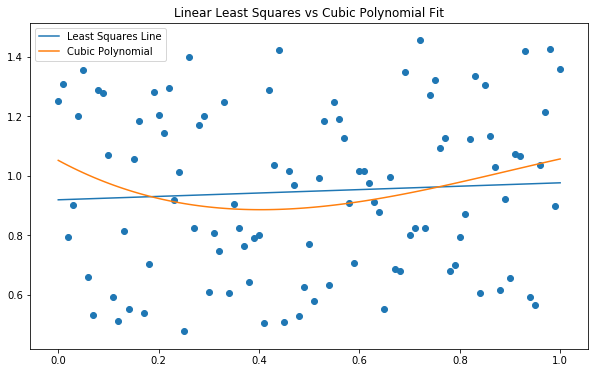

In [15]:
import numpy as np
import matplotlib.pyplot as plt


# --- PART A ---
X1 = np.arange(0, 1.01, .01)
m = np.random.rand()
b = np.random.rand()

Y = m*X1 + b + np.random.rand(X1.size)

print("Random Slope:", m, "Random Intercept:", b)

# Linear Least Squares
B = np.vstack([X1, np.ones(len(X1))]).T
n, d = np.linalg.lstsq(B, Y, rcond=None)[0]

Y_linear = n*X1 + d

# Cubic Polynomial Fit
coeffs = np.polyfit(X1, Y, 3)
Y_poly = np.polyval(coeffs, X1)

# MSE
mse_linear = np.mean((Y - Y_linear)**2)
mse_poly = np.mean((Y - Y_poly)**2)

# R^2
ss_tot = np.sum((Y - np.mean(Y))**2)

r2_linear = 1 - (np.sum((Y-Y_linear)**2) / ss_tot)
r2_poly = 1 - (np.sum((Y-Y_poly)**2) / ss_tot)

print("\nLinear Fit")
print("MSE:", mse_linear)
print("R^2:", r2_linear)

print("\nCubic Polynomial Fit")
print("MSE:", mse_poly)
print("R^2:", r2_poly)

if mse_linear < mse_poly:
    print("\nLinear model is the better fit")
else:
    print("\nPolynomial model is the better fit")

plt.figure(figsize=(10,6))
plt.title("Linear Least Squares vs Cubic Polynomial Fit")
plt.scatter(X1, Y)
plt.plot(X1, Y_linear, label="Least Squares Line")
plt.plot(X1, Y_poly, label="Cubic Polynomial")
plt.legend()
plt.show()

In [2]:
# --- PART B ---

print("\nTesting Polynomial Degrees\n")

for degree in range(1,10):

    coeffs = np.polyfit(X1, Y, degree)
    Y_poly = np.polyval(coeffs, X1)

    mse = np.mean((Y - Y_poly)**2)

    ss_tot = np.sum((Y - np.mean(Y))**2)
    r2 = 1 - (np.sum((Y-Y_poly)**2)/ss_tot)

    print("Degree:", degree)
    print("MSE:", mse)
    print("R^2:", r2)
    print()


Testing Polynomial Degrees

Degree: 1
MSE: 0.07026558839924768
R^2: 0.3960600382029229

Degree: 2
MSE: 0.06975411470816059
R^2: 0.4004562072024648

Degree: 3
MSE: 0.0697509579217154
R^2: 0.40048334010675757

Degree: 4
MSE: 0.0696184292218446
R^2: 0.40162243791779717

Degree: 5
MSE: 0.06403790117492225
R^2: 0.44958765065202777

Degree: 6
MSE: 0.06357946618463814
R^2: 0.4535279465611073

Degree: 7
MSE: 0.06354546769434292
R^2: 0.4538201670832409

Degree: 8
MSE: 0.06344491757610789
R^2: 0.45468440569489976

Degree: 9
MSE: 0.06208450224091654
R^2: 0.4663773154716635



Vandermonde Polynomial Fit (Degree 3)
MSE: 0.08088918929348818
R^2: 0.07846952357829329


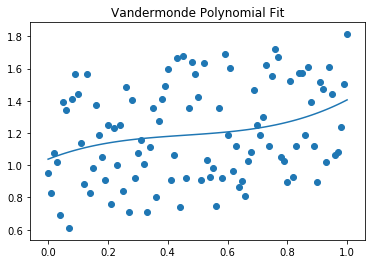

In [12]:
# --- PART C ---#

degree = 3

V = np.vander(X1, degree+1)

coefficients = np.linalg.lstsq(V, Y, rcond=None)[0]

# FIX: reverse coefficient order
polynomial = np.poly1d(coefficients)

Y_vander = polynomial(X1)

mse_vander = np.mean((Y - Y_vander)**2)

ss_tot = np.sum((Y - np.mean(Y))**2)
r2_vander = 1 - (np.sum((Y-Y_vander)**2)/ss_tot)

print("Vandermonde Polynomial Fit (Degree 3)")
print("MSE:", mse_vander)
print("R^2:", r2_vander)

plt.title("Vandermonde Polynomial Fit")
plt.scatter(X1, Y)
plt.plot(X1, Y_vander)
plt.show()